# ROMY - Barometer

In [1]:
import os
import obspy as obs
import matplotlib.pyplot as plt
import numpy as np

from pandas import DataFrame
from obspy import read_inventory, Stream
from scipy.signal import hilbert

from andbro__read_sds import __read_sds

In [2]:
from functions.get_mean_promy_pressure import __get_mean_promy_pressure
from functions.get_mean_rmy_pressure import __get_mean_rmy_pressure

In [3]:
if os.uname().nodename == 'lighthouse':
    root_path = '/home/andbro/'
    data_path = '/home/andbro/kilauea-data/'
    archive_path = '/home/andbro/freenas/'
    bay_path = '/home/andbro/ontap-ffb-bay200/'
    lamont_path = '/home/andbro/lamont/'
elif os.uname().nodename == 'kilauea':
    root_path = '/home/brotzer/'
    data_path = '/import/kilauea-data/'
    archive_path = '/import/freenas-ffb-01-data/'
    bay_path = '/import/ontap-ffb-bay200/'
    lamont_path = '/lamont/'
elif os.uname().nodename in ['lin-ffb-01', 'ambrym', 'hochfelln']:
    root_path = '/home/brotzer/'
    data_path = '/import/kilauea-data/'
    archive_path = '/import/freenas-ffb-01-data/'
    bay_path = '/import/ontap-ffb-bay200/'
    lamont_path = '/lamont/'

## Configurations

In [4]:
config = {}

# output path for figures
config['path_to_figs'] = data_path+"romy_baro/figures/"

# path to data archive
config['path_to_data'] = data_path+"romy_events/data/"

# path to data sds
config['path_to_sds'] = archive_path+"temp_archive/"
config['path_to_sds2'] = bay_path+"mseed_online/archive/"


# adjust time interval
# example 1
config['tbeg'] = obs.UTCDateTime("2024-03-04 05:00")
config['tend'] = obs.UTCDateTime("2024-03-04 07:00")
config['toffset'] = 3*3600

# example 2
# config['tbeg'] = obs.UTCDateTime("2024-04-23 02:00")
# config['tend'] = obs.UTCDateTime("2024-04-23 05:00")
# config['toffset'] = .5*3600

# example 3
# config['t1'] = obs.UTCDateTime("2024-09-04 16:00")
# config['t2'] = obs.UTCDateTime("2024-09-04 20:00")
# config['toffset'] = 3*3600

# example 4
# config['tbeg'] = obs.UTCDateTime("2024-04-24 06:00")
# config['tend'] = obs.UTCDateTime("2024-04-24 18:00")
# config['toffset'] = 1*3600

# example 5
# config['tbeg'] = obs.UTCDateTime("2024-08-31 15:00")
# config['tend'] = obs.UTCDateTime("2024-08-31 19:00")
# config['toffset'] = 1*3600

# example 6
config['tbeg'] = obs.UTCDateTime("2024-10-27 03:30")
config['tend'] = obs.UTCDateTime("2024-10-27 07:00")
config['toffset'] = 1*3600

# example 10
# config['tbeg'] = obs.UTCDateTime("2024-08-29 15:00")
# config['tend'] = obs.UTCDateTime("2024-08-29 17:00")
# config['toffset'] = .2*3600

# ROMY coordinates
config['sta_lon'] = 11.275501
config['sta_lat'] = 48.162941

config['loc'] = "40"

config['fmin'], config['fmax'] = 0.8e-3, 10e-3

## Load Data

### Load ROMY Data

In [50]:
st0 = obs.Stream()

st0 += __read_sds(config['path_to_sds'],
                  f"BW.ROMY.{config['loc']}.BJZ",
                  config['tbeg']-config['toffset'],
                  config['tend']+config['toffset']
                 )
st0 += __read_sds(config['path_to_sds'],
                  f"BW.ROMY.{config['loc']}.BJN",
                  config['tbeg']-config['toffset'],
                  config['tend']+config['toffset']
                 )
st0 += __read_sds(config['path_to_sds'],
                  f"BW.ROMY.{config['loc']}.BJE",
                  config['tbeg']-config['toffset'],
                  config['tend']+config['toffset']
                 )

st0 = st0.detrend("demean")
st0 = st0.detrend("linear")

st0 = st0.merge(fill_value=0)

# reverse horizontal components to match tilt definition (instead of rotation)
st0.select(channel="*N")[0].stats.channel = "BJE"
st0.select(channel="*E")[0].stats.channel = "BJN"

st0

# st0.plot(equal_scale=False);

3 Trace(s) in Stream:
BW.ROMY.40.BJE | 2024-10-27T02:29:59.997200Z - 2024-10-27T07:59:59.997200Z | 20.0 Hz, 396001 samples
BW.ROMY.40.BJN | 2024-10-27T02:30:00.012599Z - 2024-10-27T08:00:00.012599Z | 20.0 Hz, 396001 samples
BW.ROMY.40.BJZ | 2024-10-27T02:30:00.006400Z - 2024-10-27T08:00:00.006400Z | 20.0 Hz, 396001 samples


3 Trace(s) in Stream:
BW.ROMY.40.BJN | 2024-10-27T02:29:59.997200Z - 2024-10-27T07:59:59.997200Z | 20.0 Hz, 396001 samples
BW.ROMY.40.BJE | 2024-10-27T02:30:00.012599Z - 2024-10-27T08:00:00.012599Z | 20.0 Hz, 396001 samples
BW.ROMY.40.BJZ | 2024-10-27T02:30:00.006400Z - 2024-10-27T08:00:00.006400Z | 20.0 Hz, 396001 samples

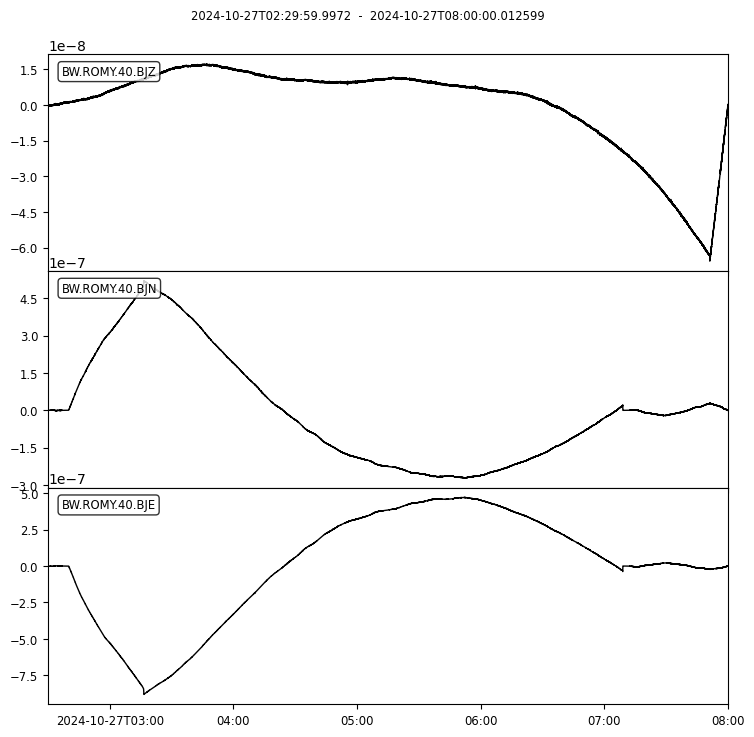

In [6]:
til1 = st0.select(station=f"ROMY", channel="*J*").copy()

til1 = til1.detrend("demean")

til1 = til1.integrate("spline")

til1.plot(equal_scale=False);

### Load FFBI Data

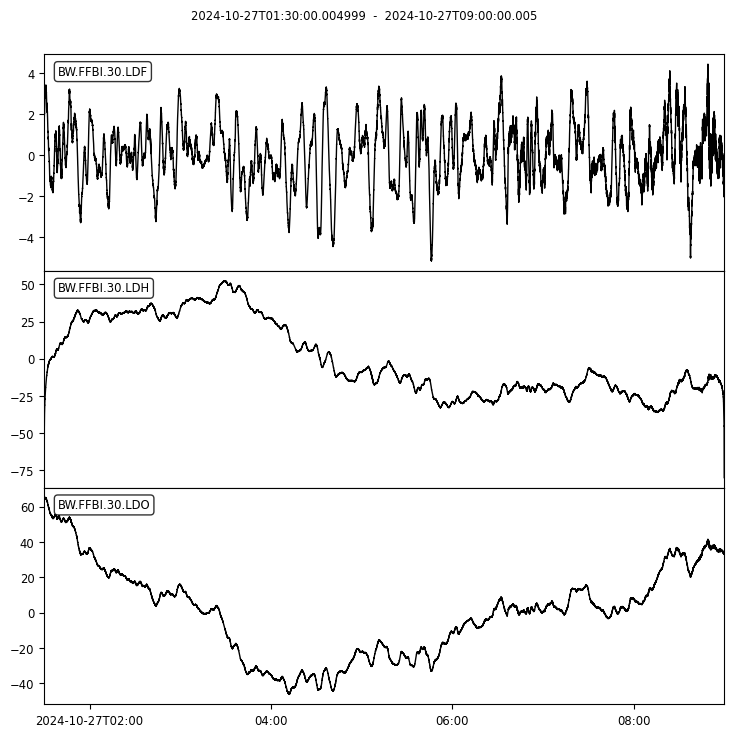

In [7]:
ffbi_inv = read_inventory(root_path+"/Documents/ROMY/ROMY_infrasound/station_BW_FFBI.xml")

ffbi0 = Stream()
ffbi0 += __read_sds(archive_path+"temp_archive/",
                    "BW.FFBI.30.LDF",
                    config['tbeg']-config['toffset']-3600,
                    config['tend']+config['toffset']+3600)
ffbi0 += __read_sds(archive_path+"temp_archive/",
                    "BW.FFBI.30.LDO",
                    config['tbeg']-config['toffset']-3600,
                    config['tend']+config['toffset']+3600)

# to pascal
for tr in ffbi0:
    if "O" in tr.stats.channel:
        tr.data *= 100

ffbi0.merge();

ffbi0 = ffbi0.detrend("demean")
ffbi0 = ffbi0.detrend("linear")

# add hilbert pressure
sth = ffbi0.select(channel="*O").copy()
for tr in sth:
    tr.data = np.imag(hilbert(tr.data))
    tr.stats.channel = "LDH"

ffbi0 += sth.copy()

ffbi0.plot(equal_scale=False);

### Load PROMY Data

In [8]:
# promy = __get_mean_promy_pressure(["03", "04", "05", "07", "09"], config['tbeg'], config['tend'], archive_path, plot=True)

### Load BRMY Data

In [9]:
def __get_mean_rmy_pressure(stations, t1, t2, path_to_data, plot=False):

    import matplotlib.pyplot as plt
    from andbro__read_sds import __read_sds
    from obspy import Stream
    from functions.interpolate_nan import __interpolate_nan
    from functions.smoothing import __smooth
    from obspy.signal.cross_correlation import correlate, xcorr_max
    from numpy import arange, roll, array

    ps0 = Stream()

    for jj in stations:
        if jj == "PROMY":
            loc, cha = "03", "LDI"
        else:
            loc, cha = "", "LDO"

        ps0 += __read_sds(path_to_data+"temp_archive/", f"BW.{jj}.{loc}.{cha}", t1-10, t2+10)

    ps0 = ps0.trim(t1, t2)

    # update stations
    stations = []
    for tr in ps0:
        stations.append(tr.stats.station)

        # smooth data
        tr.data = __smooth(tr.data, 60)

    # convert from hPa to Pa
    for tr in ps0:
        if "03" in tr.stats.location:
            tr.data = __interpolate_nan(tr.data)
        else:
            tr.data = tr.data * 100 # scale to Pa
            tr.data = __interpolate_nan(tr.data)

    # equalize number of samples
    npts_min = ps0[0].stats.npts
    for tr in ps0:
        if tr.stats.npts < npts_min:
            npts_min
    for tr in ps0:
        diff = abs(tr.stats.npts - npts_min)
        if diff != 0:
            tr.data = tr.data[:-diff]

    ps0 = ps0.detrend("linear")
    ps0 = ps0.detrend("simple")
    ps0 = ps0.filter("highpass", freq=1/(6*3600), corners=4, zerophase=True);

    # shift traces to compute mean of array
    shifted = []

    for i, sta in enumerate(stations):

        if i == 0:
            arr0 = ps0.select(station=sta)[0].data
            shifted.append(arr0)
            continue
        else:
            arr1 = ps0.select(station=sta)[0].data

        Nshift = len(arr0)

        dt = ps0[0].stats.delta

        ccf1 = correlate(arr0, arr1, shift=Nshift, demean=False, normalize='naive', method='fft')

        cclags = arange(-Nshift, Nshift+1) * dt

        shift1, value1 = xcorr_max(ccf1)
        print(sta, f"shift: {round(shift1/60, 2)}min", f"CC: {round(value1, 2)}")

        arr1_shifted = roll(arr1, shift1)

        shifted.append(arr1_shifted)

        # compute mean
        _mean = array([])
        for i, arr in enumerate(shifted):
            if i == 0:
                _mean = arr
            else:
                _mean = _mean + arr

    mean = ps0[0].copy()
    mean.stats.station = "RMY"
    mean.stats.location = "00"
    mean.stats.channel = "LDO"
    mean.data = _mean/(i+1)

    # checkup plot
    if plot:
        times = ps0[0].times()/3600
        fig = plt.figure(figsize=(15, 5))
        for i, x in enumerate(shifted):
            plt.plot(times, x, label=stations[i], zorder=2)
        plt.plot(times, mean.data, "k", zorder=2)
        plt.legend()
        plt.grid(ls="--", color="grey", alpha=0.4)
        plt.ylabel("Pressure (Pa)", fontsize=12)
        plt.xlabel("Time (hour)", fontsize=12)
        plt.show();

    if plot:
        return mean, fig
    else:
        return mean, _

In [10]:
# brmy, _ = __get_mean_rmy_pressure(["PROMY", "ALFT", "TON", "BIB", "GELB", "GRMB"],
#                                   config['tbeg']-config['toffset'],
#                                   config['tend']+config['toffset'],
#                                   archive_path,
#                                   plot=True,
#                                  )


### Load BRMY Gradient Data

In [11]:
gbrmy = Stream()
gbrmy += __read_sds(archive_path+"temp_archive/",
                    "BW.BRMY..BDN",
                    config['tbeg']-config['toffset'],
                    config['tend']+config['toffset']
                   )
gbrmy += __read_sds(archive_path+"temp_archive/",
                    "BW.BRMY..BDE",
                    config['tbeg']-config['toffset'],
                    config['tend']+config['toffset']
                   )

# gbrmy.plot();

### Load FUR Data

3 Trace(s) in Stream:
GR.FUR..BHE | 2024-10-27T02:29:59.989999Z - 2024-10-27T07:59:59.989999Z | 20.0 Hz, 396001 samples
GR.FUR..BHN | 2024-10-27T02:29:59.990000Z - 2024-10-27T07:59:59.990000Z | 20.0 Hz, 396001 samples
GR.FUR..BHZ | 2024-10-27T02:29:59.990000Z - 2024-10-27T07:59:59.990000Z | 20.0 Hz, 396001 samples

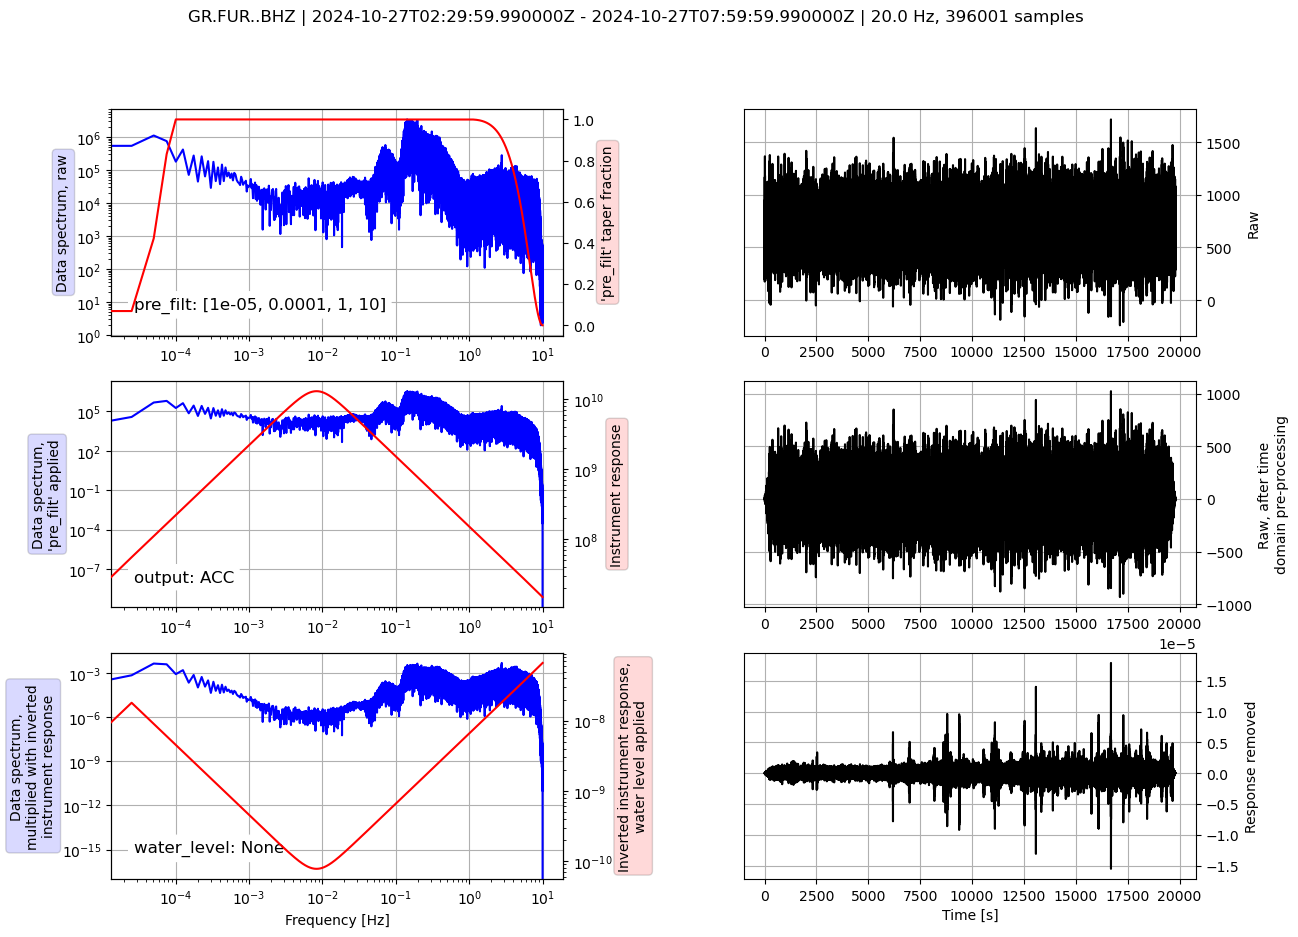

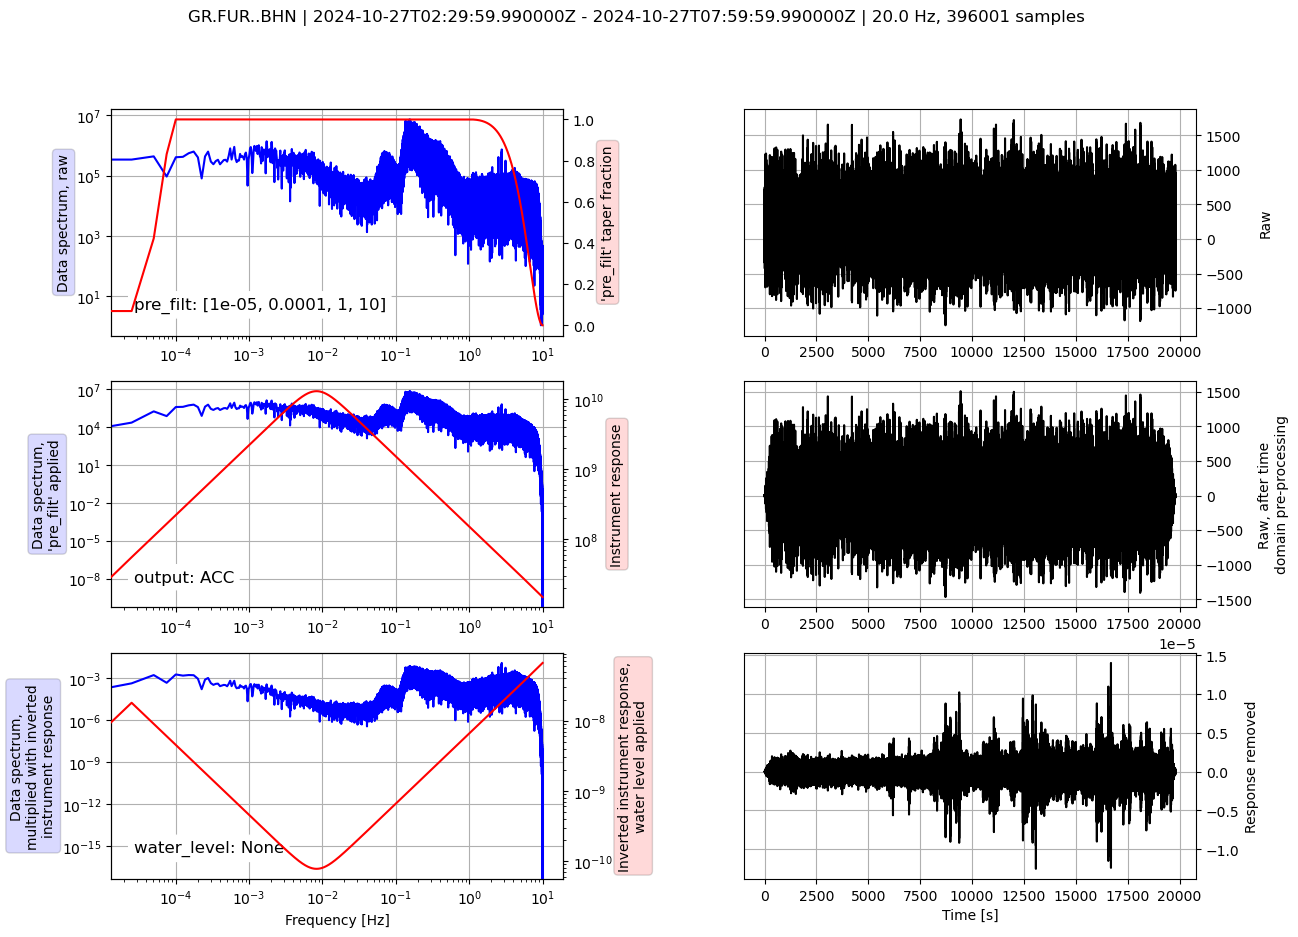

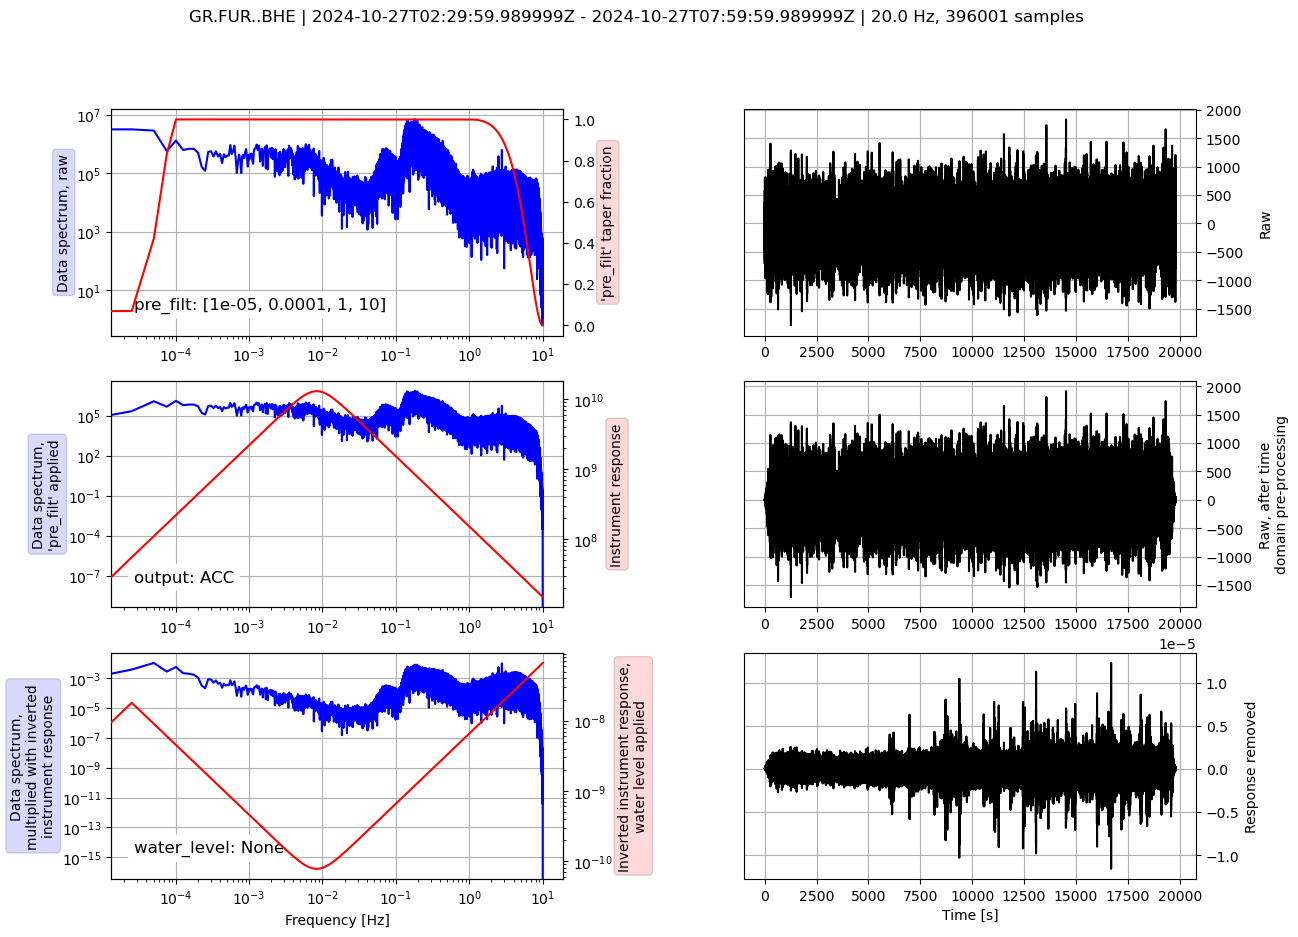

In [12]:
fur = Stream()
fur += __read_sds(config['path_to_sds2'],
                  "GR.FUR..BHZ",
                  config['tbeg']-config['toffset'],
                  config['tend']+config['toffset']
                 )
fur += __read_sds(config['path_to_sds2'],
                  "GR.FUR..BHN",
                  config['tbeg']-config['toffset'],
                  config['tend']+config['toffset']
                 )
fur += __read_sds(config['path_to_sds2'],
                  "GR.FUR..BHE",
                  config['tbeg']-config['toffset'],
                  config['tend']+config['toffset']
                 )

fur_inv = read_inventory(data_path+"/stationxml_ringlaser/station_GR_FUR.xml")

fur = fur.rotate('->ZNE', inventory=fur_inv)

fur = fur.remove_response(inventory=fur_inv,
                          output="ACC",
                          water_level=None,
                          pre_filt=[1e-5, 1e-4, 1, 10],
                          plot=True
                         )

# fur = fur.differentiate()

fur = fur.merge(fill_value="interpolate")

# convert to tilt
for tr in fur:
    tr.data /= 9.81 # m/s^2

    # tr.data *= 2
fur

### Join to one Stream

11 Trace(s) in Stream:
BW.ROMY.40.BJN | 2024-10-27T02:29:59.997200Z - 2024-10-27T07:59:59.997200Z | 20.0 Hz, 396001 samples
BW.ROMY.40.BJE | 2024-10-27T02:30:00.012599Z - 2024-10-27T08:00:00.012599Z | 20.0 Hz, 396001 samples
BW.ROMY.40.BJZ | 2024-10-27T02:30:00.006400Z - 2024-10-27T08:00:00.006400Z | 20.0 Hz, 396001 samples
BW.FFBI.30.LDF | 2024-10-27T01:30:00.004999Z - 2024-10-27T09:00:00.004999Z | 2.0 Hz, 54001 samples
BW.FFBI.30.LDO | 2024-10-27T01:30:00.005000Z - 2024-10-27T09:00:00.005000Z | 2.0 Hz, 54001 samples
BW.FFBI.30.LDH | 2024-10-27T01:30:00.005000Z - 2024-10-27T09:00:00.005000Z | 2.0 Hz, 54001 samples
BW.BRMY..BDN   | 2024-10-27T02:30:00.000000Z - 2024-10-27T08:00:00.000000Z | 1.0 Hz, 19801 samples
BW.BRMY..BDE   | 2024-10-27T02:30:00.000000Z - 2024-10-27T08:00:00.000000Z | 1.0 Hz, 19801 samples
GR.FUR..BHE    | 2024-10-27T02:29:59.989999Z - 2024-10-27T07:59:59.989999Z | 20.0 Hz, 396001 samples
GR.FUR..BHN    | 2024-10-27T02:29:59.990000Z - 2024-10-27T07:59:59.990000Z | 2

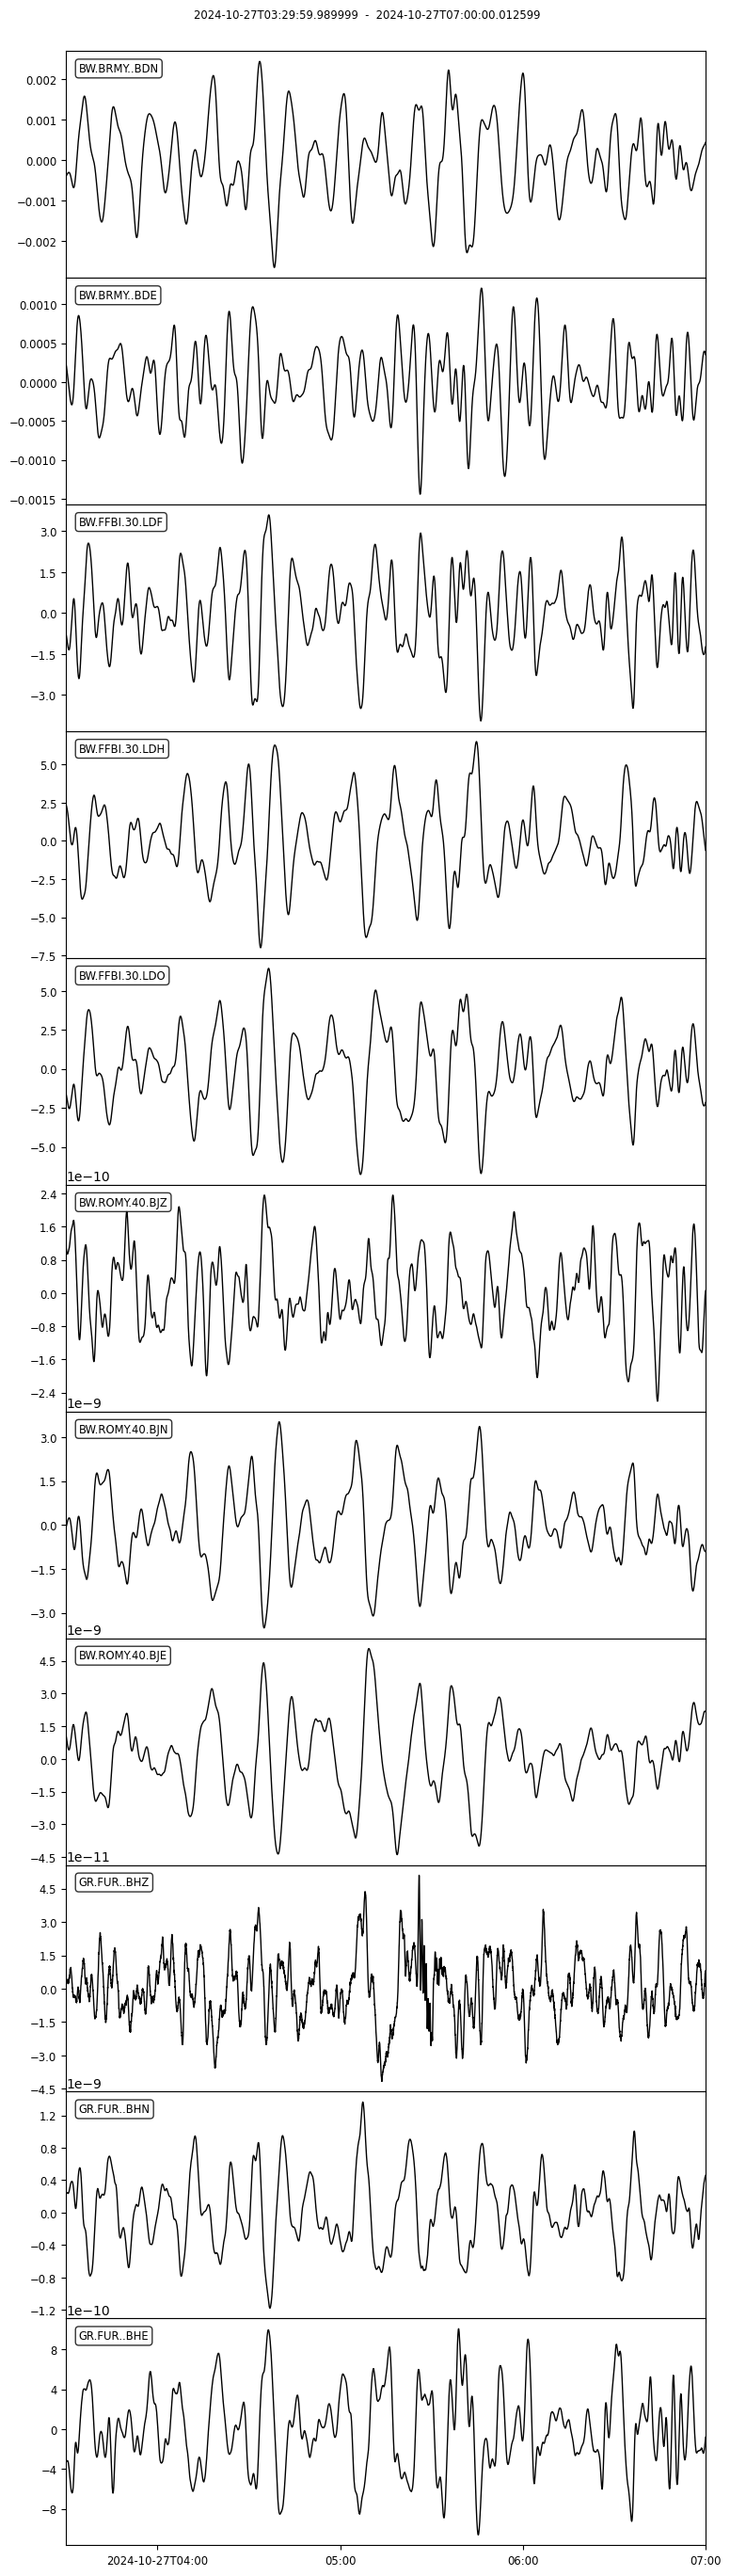

In [13]:
stall = Stream()

# add tilt
stall += til1.copy()

# add pressure
stall += ffbi0.copy()

# add pressure gradient
stall += gbrmy.copy()

# add seismometer tilt
stall += fur.copy()

try:
    stall += promy.copy()
except:
    pass
try:
    stall += brmy.copy()
except:
    pass

print(stall)

stall = stall.detrend("linear")
stall = stall.taper(0.05, type="cosine")
stall = stall.filter("highpass", freq=config['fmin'], corners=2, zerophase=True)
stall = stall.filter("lowpass", freq=config['fmax'], corners=2, zerophase=True)

for tr in stall:
    if tr.stats.station in ["ROMY"]:
        tr = tr.decimate(2, no_filter=True)
        tr = tr.decimate(10, no_filter=True)
    if tr.stats.station in ["FFBI"]:
        tr = tr.decimate(2, no_filter=True)
    if tr.stats.station in ["FUR"]:
        tr = tr.decimate(2, no_filter=True)
        tr = tr.decimate(10, no_filter=True)

stall = stall.trim(config['tbeg'], config['tend'])

# equalize size of traces
l_min = min([len(tr.data) for tr in stall])
for tr in stall:
    tr.data = tr.data[:l_min]

print(stall)

stall.plot(equal_scale=False);

In [14]:
def __makeplot(stt):

    from scipy.signal import hilbert
    from numpy import imag

    Nrow, Ncol = 5, 1

    yscale = 1e9

    font = 12

    ch = "*DO"

    tscale, tunit = 1/60, "min"

    fig, ax = plt.subplots(Nrow, Ncol, figsize=(15, 12))

    ax[0].plot(stt.select(component="Z")[0].times(reftime=config['tbeg'])*tscale,
               stt.select(component="Z")[0].data*yscale,
               label="ROMY.Z", color="tab:blue")

    ax[1].plot(stt.select(component="N")[0].times(reftime=config['tbeg'])*tscale,
               stt.select(component="N")[0].data*yscale,
               label="ROMY.N", color="tab:orange")

    ax[2].plot(stt.select(component="E")[0].times(reftime=config['tbeg'])*tscale,
               stt.select(component="E")[0].data*yscale,
               label="ROMY.E", color="tab:red")

    ax[3].plot(stt.select(channel="LDO")[0].times(reftime=config['tbeg'])*tscale,
               stt.select(channel="LDO")[0].data,
               label=f"FFBI.O", color="k")

    ax[4].plot(stt.select(channel="LDH")[0].times(reftime=config['tbeg'])*tscale,
               stt.select(channel="LDH")[0].data,
               label=f"hilbert(FFBI.H)", color="darkgrey")

    ax[0].fill_between(stt.select(component="Z")[0].times(reftime=config['tbeg'])*tscale, 0,
               stt.select(component="Z")[0].data*yscale,
               where=stt.select(component="Z")[0].data*yscale>0, interpolate=True,
               color="tab:blue", alpha=0.5)

    ax[1].fill_between(stt.select(component="N")[0].times(reftime=config['tbeg'])*tscale, 0,
               stt.select(component="N")[0].data*yscale,
               where=stt.select(component="N")[0].data*yscale>0, interpolate=True,
               color="tab:orange", alpha=0.5)

    ax[2].fill_between(stt.select(component="E")[0].times(reftime=config['tbeg'])*tscale, 0,
               stt.select(component="E")[0].data*yscale,
               where=stt.select(component="E")[0].data*yscale>0, interpolate=True,
               color="tab:red", alpha=0.5)

    ax[3].fill_between(stt.select(channel="LDO")[0].times(reftime=config['tbeg'])*tscale, 0,
               stt.select(channel="LDO")[0].data,
               where=stt.select(channel="LDO")[0].data>0, interpolate=True,
               color="k", alpha=0.5)

    ax[4].fill_between(stt.select(channel="LDH")[0].times(reftime=config['tbeg'])*tscale, 0,
               stt.select(channel="LDH")[0].data,
               where=stt.select(channel="LDH")[0].data>0, interpolate=True,
               color="darkgrey", alpha=0.5)

    for _n in range(Nrow):
        # ax[_n].grid(ls=":", zorder=0)
        ax[_n].legend(loc=1)
        ax[_n].spines[['right', 'top']].set_visible(False)
        if _n < Nrow-1:
            ax[_n].spines[['bottom']].set_visible(False)

    ax[0].set_ylabel("Tilt (nrad)", fontsize=font)
    ax[1].set_ylabel("Tilt (nrad)", fontsize=font)
    ax[2].set_ylabel("Tilt (nrad)", fontsize=font)

    ax[3].set_ylabel("Pressure (Pa)", fontsize=font)
    ax[4].set_ylabel("Pressure (Pa)", fontsize=font)

    ax[Nrow-1].set_xlabel(f"Time ({tunit}) from {config['tbeg']}", fontsize=font)

    ax[0].set_title(f"{fmin} - {fmax} Hz")

    for _k, ll in enumerate(['(a)', '(b)', '(c)', '(d)', '(e)']):
        ax[_k].text(.005, .97, ll, ha='left', va='top', transform=ax[_k].transAxes, fontsize=font+2)

    plt.show();
    return fig

# fig = __makeplot(stall);

# fig.savefig(config['path_to_figs']+f"RB_{config['tbeg'].date}_waveforms.png", format="png", dpi=150, bbox_inches='tight')


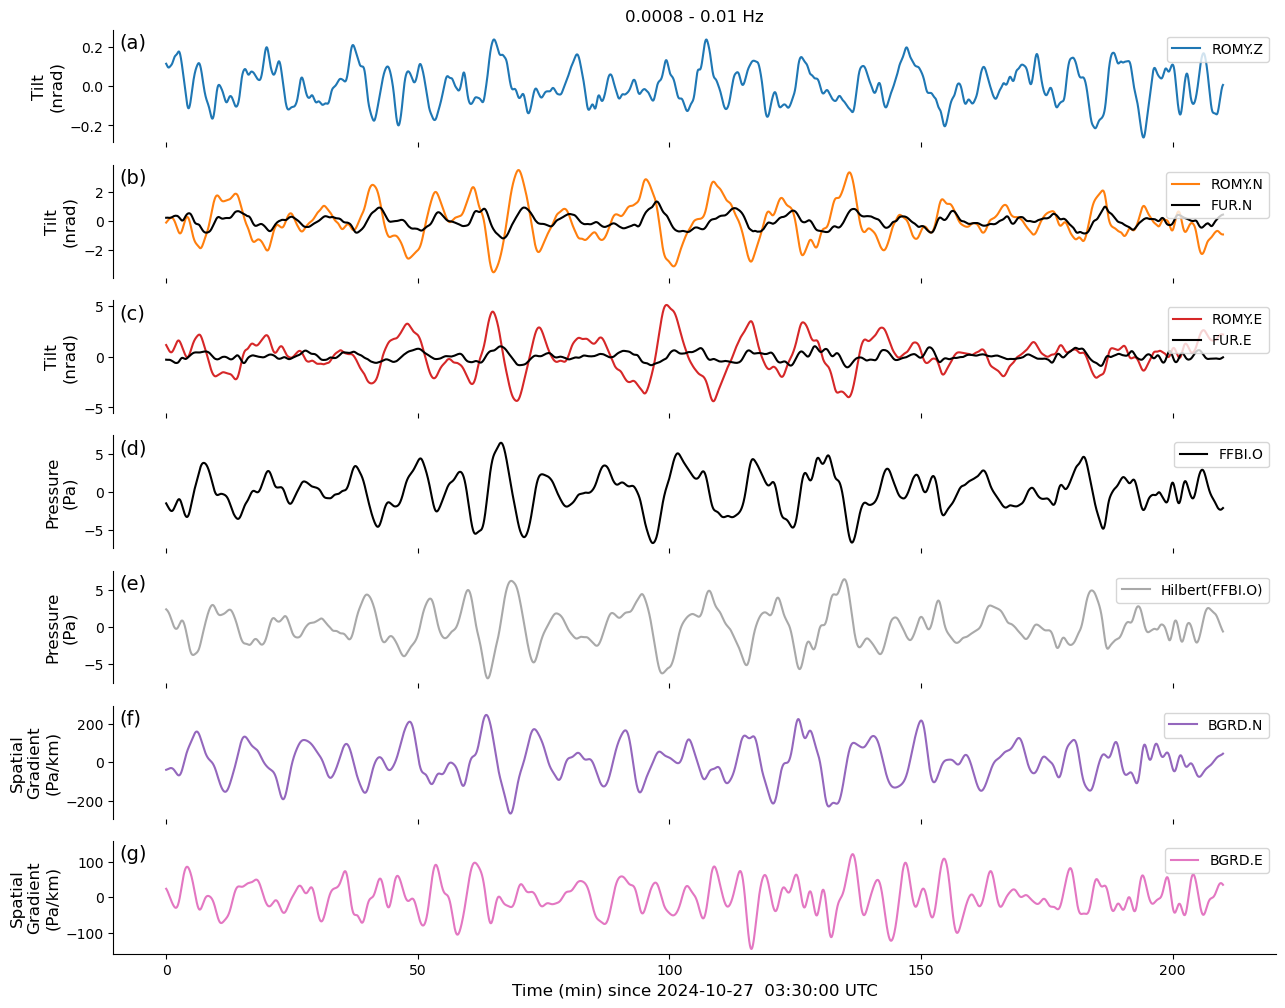

NameError: name 'code' is not defined

In [46]:
def __makeplot6(stb, fur=True):

    from scipy.signal import hilbert
    from numpy import imag

    Nrow, Ncol = 7, 1

    yscale = 1e9

    fscale = 1

    gscale = 1e5

    font = 12

    ch = "*DO"

    tscale, tunit = 1/60, "min"

    fig, ax = plt.subplots(Nrow, Ncol, figsize=(15, 12), sharex=True)

    ax[0].plot(stb.select(station="ROMY", component="Z")[0].times(reftime=config['tbeg'])*tscale,
               stb.select(station="ROMY", component="Z")[0].data*yscale,
               label="ROMY.Z", color="tab:blue")
    # ax[0].plot(stb.select(station="FUR", component="Z")[0].times(reftime=config['tbeg'])*tscale,
    #            stb.select(station="FUR", component="Z")[0].data*yscale*fscale,
    #            label="FUR.Z", color="k", ls="-")

    ax[1].plot(stb.select(station="ROMY", component="N")[0].times(reftime=config['tbeg'])*tscale,
               stb.select(station="ROMY", component="N")[0].data*yscale,
               label="ROMY.N", color="tab:orange")
    if fur:
        ax[1].plot(stb.select(station="FUR", component="N")[0].times(reftime=config['tbeg'])*tscale,
                   stb.select(station="FUR", component="N")[0].data*yscale*fscale,
                   label="FUR.N", color="k", ls="-")

    ax[2].plot(stb.select(station="ROMY", component="E")[0].times(reftime=config['tbeg'])*tscale,
               stb.select(station="ROMY", component="E")[0].data*yscale,
               label="ROMY.E", color="tab:red")
    if fur:
        ax[2].plot(stb.select(station="FUR", component="E")[0].times(reftime=config['tbeg'])*tscale,
                   stb.select(station="FUR", component="E")[0].data*yscale*fscale,
                   label="FUR.E", color="k", ls="-")

    ax[3].plot(stb.select(channel="LDO")[0].times(reftime=config['tbeg'])*tscale,
               stb.select(channel="LDO")[0].data,
               label=f"FFBI.O", color="k")

    ax[4].plot(stb.select(channel="LDH")[0].times(reftime=config['tbeg'])*tscale,
               stb.select(channel="LDH")[0].data,
               label=f"Hilbert(FFBI.O)", color="darkgrey")

    ax[5].plot(stb.select(channel="BDN")[0].times(reftime=config['tbeg'])*tscale,
               stb.select(channel="BDN")[0].data*gscale,
               label=f"BGRD.N", color="tab:purple")

    ax[6].plot(stb.select(channel="BDE")[0].times(reftime=config['tbeg'])*tscale,
               stb.select(channel="BDE")[0].data*gscale,
               label=f"BGRD.E", color="tab:pink")

    for _n in range(Nrow):
        # ax[_n].grid(ls=":", zorder=0)
        ax[_n].legend(loc=1)

        ax[_n].spines[['right', 'top']].set_visible(False)
        if _n < Nrow-1:
            ax[_n].spines[['bottom']].set_visible(False)

        yl = max([abs(y) for y in ax[_n].get_ylim()])
        ax[_n].set_ylim(-yl, yl)

    ax[0].set_ylabel("Tilt\n(nrad)", fontsize=font)
    ax[1].set_ylabel("Tilt\n(nrad)", fontsize=font)
    ax[2].set_ylabel("Tilt\n(nrad)", fontsize=font)

    ax[3].set_ylabel("Pressure\n(Pa)", fontsize=font)
    ax[4].set_ylabel("Pressure\n(Pa)", fontsize=font)

    ax[5].set_ylabel("Spatial\nGradient\n(Pa/km)", fontsize=font)
    ax[6].set_ylabel("Spatial\nGradient\n(Pa/km)", fontsize=font)

    ax[Nrow-1].set_xlabel(f"Time ({tunit}) since {config['tbeg'].date}  {str(config['tbeg'].time)[:9]} UTC", fontsize=font)

    ax[0].set_title(f"{config['fmin']} - {config['fmax']} Hz")

    for _k, ll in enumerate(['(a)', '(b)', '(c)', '(d)', '(e)', '(f)', '(g)']):
        ax[_k].text(.005, .97, ll, ha='left', va='top', transform=ax[_k].transAxes, fontsize=font+2)

    plt.show();
    return fig

fig = __makeplot6(stall, fur=True);

fig.savefig(config['path_to_figs']+f"RB_{config['tbeg'].date}_{code}_waveforms_gradient.png", format="png", dpi=150, bbox_inches='tight')


In [16]:
from obspy.signal.cross_correlation import correlate, xcorr_max
from numpy import arange, roll, array, sqrt, nanmean, nanstd

# cross-correlate
arr0 = stall.select(station="ROMY", channel="*E")[0].data
arr1 = stall.select(station="FUR", channel="*E")[0].data

dt = stall.select(station="ROMY", channel="*N")[0].stats.delta

Nshift = len(arr0)

ccf = correlate(arr0, arr1, shift=Nshift, demean=False, normalize='naive', method='fft')

# get shifts
cclags = arange(-Nshift, Nshift+1) * dt

# find maximum
shift_max, value_max = xcorr_max(ccf, abs_max=False)

print(shift_max, value_max)

-107 0.5976172799141515


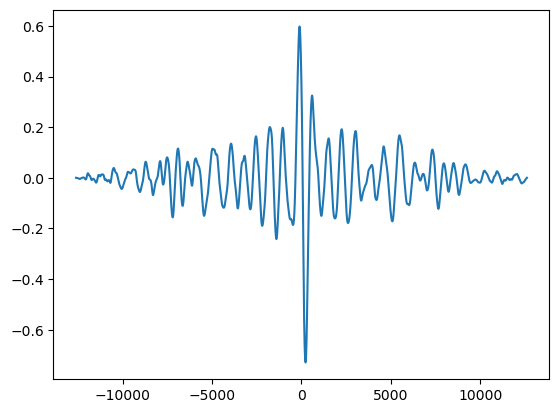

In [17]:
plt.plot(cclags, ccf)

In [18]:
def __makeplot(stt):

    from scipy.signal import hilbert
    from numpy import imag

    Nrow, Ncol = 2, 2

    ch = "O"

    font = 12

    yscale = 1e9

    tscale, tunit = 1/3600, "hours"

    fig, ax = plt.subplots(Nrow, Ncol, figsize=(15, 8))

    ax[0, 0].scatter(imag(hilbert(stt.select(component=ch)[0].data)),
                    stt.select(component="N")[0].data*yscale,
                    label="ROMY-N", color="tab:orange", s=5
                    )
    ax[0, 0].set_xlabel("H(Pressure) (Pa)", fontsize=font)
    ax[0, 0].set_ylabel("Tilt (nrad)", fontsize=font)

    ax[0, 1].scatter(stt.select(component=ch)[0].data,
                    stt.select(component="N")[0].data*yscale,
                    label="ROMY-N", color="tab:orange", s=5,
                    )
    ax[0, 1].set_xlabel("Pressure (Pa)", fontsize=font)
    ax[0, 1].set_ylabel("Tilt (nrad)", fontsize=font)

    ax[1, 0].scatter(imag(hilbert(stt.select(component=ch)[0].data)),
                    stt.select(component="E")[0].data*yscale,
                    label="ROMY-E", color="tab:red", s=5
                    )
    ax[1, 0].set_xlabel("H(Pressure) (Pa)", fontsize=font)
    ax[1, 0].set_ylabel("Tilt (nrad)", fontsize=font)

    ax[1, 1].scatter(stt.select(component=ch)[0].data,
                    stt.select(component="E")[0].data*yscale,
                    label="ROMY-E", color="tab:red", s=5
                    )
    ax[1, 1].set_xlabel("Pressure (Pa)", fontsize=font)
    ax[1, 1].set_ylabel("Tilt (nrad)", fontsize=font)

    for j in range(2):
        for i in range(2):
            ax[i, j].grid(ls=":", zorder=0)
            ax[i, j].legend(loc=1)
            # ax[i, j].set_title(f"{fmin} - {fmax} Hz", fontsize=font)

    plt.show();
    return fig

# fig = __makeplot(stall);


In [19]:
def __compare_tilt_pressure(st0):

    from obspy.signal.cross_correlation import correlate, xcorr_max
    from numpy import nan_to_num, arange, array, linspace, imag, roll
    from matplotlib.gridspec import GridSpec
    from functions.compute_orthogonal_distance_regression import __compute_orthogonal_distance_regression
    from functions.smoothing import __smooth
    from scipy.signal import hilbert

    tlp = st0.copy()

    dt = tlp[0].stats.delta

    times = tlp[0].times()/3600

    ch = "*DO"

    arr0 = tlp.select(channel=ch)[0].data
    arr1 = tlp.select(component="N")[0].data
    arr2 = tlp.select(component="E")[0].data


    Nshift = len(arr0)

    ccf1 = correlate(arr0, arr1, shift=Nshift, demean=False, normalize='naive', method='fft')
    ccf2 = correlate(arr0, arr2, shift=Nshift, demean=False, normalize='naive', method='fft')

    cclags = arange(-Nshift, Nshift+1) * dt

    shift1, value1 = xcorr_max(ccf1)
    shift2, value2 = xcorr_max(ccf2)

    arr1_shifted = roll(arr1, shift1)
    arr2_shifted = roll(arr2, shift2)

    print("Nshift: ", shift1, "Tshift: ", shift1*dt, "CC: ", value1)
    print("Nshift: ", shift2, "Tshift: ", shift2*dt, "CC: ", value2)


    b1, a1 = __compute_orthogonal_distance_regression(arr0, arr1, xerr=None, yerr=None, bx=None, by=None)
    b2, a2 = __compute_orthogonal_distance_regression(arr0, arr2, xerr=None, yerr=None, bx=None, by=None)

    b1_shifted, a1_shifted = __compute_orthogonal_distance_regression(arr0, arr1_shifted, xerr=None, yerr=None, bx=None, by=None)
    b2_shifted, a2_shifted = __compute_orthogonal_distance_regression(arr0, arr2_shifted, xerr=None, yerr=None, bx=None, by=None)

    xxx = linspace(arr0.min(), arr0.max(), 100)

    Nrow, Ncol = 5, 2
    font = 12

    fig = plt.figure(figsize=(12, 10))

    gs0 = GridSpec(Nrow, Ncol, figure=fig, hspace=0)
    gs = GridSpec(Nrow, Ncol, figure=fig, hspace=0.5)

    ax1 = fig.add_subplot(gs0[0, :])
    ax2 = fig.add_subplot(gs[1, :])
    ax3 = fig.add_subplot(gs[2, :1])
    ax4 = fig.add_subplot(gs[2, 1:])
    ax5 = fig.add_subplot(gs[3, :1])
    ax6 = fig.add_subplot(gs[3, 1:])
    ax7 = fig.add_subplot(gs[4, :1])
    ax8 = fig.add_subplot(gs[4, 1:])

    axes = [ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8]
    for _k, (ax, ll) in enumerate(zip(axes, ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)', '(g)', '(h)'])):
        ax.text(.005, .97, ll, ha='left', va='top', transform=ax.transAxes, fontsize=font+2)

    plt.subplots_adjust(hspace=0.35)

    ax1.plot(times, arr0, color="black", label=f"FFBI.{ch}")
    ax1.set_ylabel("Pressure (Pa)", fontsize=font)
    ax1.get_xaxis().set_visible(False)
    ax1.legend(loc=1)

    ax2.plot(times, arr1*1e9, label="N")
    ax2.plot(times, arr2*1e9, label="E")
    ax2.legend(loc=1, ncol=2)
    ax2.set_ylabel("Tilt (nrad)", fontsize=font)
    ax2.set_xlabel("Time (hours)", fontsize=font, labelpad=1)


    ax3.scatter(arr0, arr1*1e9, color="tab:blue", s=1)
    ax3.plot(xxx, (a1+b1*xxx)*1e9, ls="--", color="k", label=f"a={a1*1e9:.2f}; b={b1*1e9:.2f}")
    ax3.set_xlabel("Pressure (Pa)", fontsize=font)
    ax3.set_ylabel("Tilt (nrad)", fontsize=font)
    ax3.legend(loc=1)

    ax4.scatter(arr0, arr2*1e9, color="tab:orange", s=1)
    ax4.plot(xxx, (a2+b2*xxx)*1e9, ls="--", color="k", label=f"a={a2*1e9:.2f}; b={b2*1e9:.2f}")
    ax4.set_xlabel("Pressure (Pa)", fontsize=font)
    ax4.set_ylabel("Tilt (nrad)", fontsize=font)
    ax4.legend(loc=4)

    ll = f"t={round(shift1*dt, 1)} s  CC={round(value1, 1)}"
    ax5.plot(cclags, ccf1, color="tab:blue", label=ll)
    ax5.set_ylabel("CC-Coeff.", fontsize=font)
    ax5.set_xlabel("Lag time (s)", fontsize=font, labelpad=0)
    ax5.set_ylim(-1, 1)
    ax5.axvline(shift1*dt, -1, 1, color="k", ls="--", zorder=0)
    ax5.scatter(shift1*dt, value1, color="k", marker="d", zorder=0)
    ax5.legend(loc=1)
    # ax5.text(.005, .97, ll, ha='left', va='top', transform=ax3.transAxes, fontsize=font)

    ll = f"t={round(shift2*dt, 1)} s  CC={round(value2, 1)}"
    ax6.plot(cclags, ccf2, color="tab:orange", label=ll)
    ax6.set_ylabel("CC-Coeff.", fontsize=font)
    ax6.set_xlabel("Lag time (s)", fontsize=font, labelpad=0)
    ax6.set_ylim(-1, 1)
    ax6.axvline(shift2*dt, -1, 1, color="k", ls="--", zorder=0)
    ax6.scatter(shift2*dt, value2, color="k", marker="d", zorder=0)
    ax6.legend(loc=1)
    # ax6.text(.005, .97, ll, ha='left', va='top', transform=ax4.transAxes, fontsize=font)


    ax7.scatter(arr0, arr1_shifted*1e9, color="tab:blue", s=1)
    ax7.plot(xxx, (a1_shifted+b1_shifted*xxx)*1e9, ls="--", color="k", label=f"a={a1_shifted*1e9:.2f}; b={b1_shifted*1e9:.2f}")
    ax7.set_xlabel("Pressure (Pa)", fontsize=font)
    ax7.set_ylabel("Tilt (nrad)", fontsize=font)
    ax7.legend(loc=1)

    ax8.scatter(arr0, arr2_shifted*1e9, color="tab:orange", s=1)
    ax8.plot(xxx, (a2_shifted+b2_shifted*xxx)*1e9, ls="--", color="k", label=f"a={a2_shifted*1e9:.2f}; b={b2_shifted*1e9:.2f}")
    ax8.set_xlabel("Pressure (Pa)", fontsize=font)
    ax8.set_ylabel("Tilt (nrad)", fontsize=font)
    ax8.legend(loc=4)

    for ax in [ax3, ax4, ax5, ax6, ax7, ax8]:
        ax.grid(ls=":", alpha=0.5, zorder=0, color="grey")

    plt.show();
    return fig

# fig = __compare_tilt_pressure(stall)

# fig.savefig(config['path_to_figs']+f"RB__{config['tbeg'].date}_waveforms_cc.png", format="png", dpi=150, bbox_inches='tight')


In [20]:
def __compare_tilt_pressure(st0):

    from obspy.signal.cross_correlation import correlate, xcorr_max
    from numpy import nan_to_num, arange, array, linspace, imag, roll
    from matplotlib.gridspec import GridSpec
    from functions.compute_orthogonal_distance_regression import __compute_orthogonal_distance_regression
    from functions.smoothing import __smooth
    from scipy.signal import hilbert

    tlp = st0.copy()

    dt = tlp[0].stats.delta

    times = tlp[0].times()/3600

    yscale = 1e9

    ch = "*DO"

    arr0 = imag(hilbert(tlp.select(channel=ch)[0].data))
    arr1 = tlp.select(component="N")[0].data
    arr2 = tlp.select(component="E")[0].data

    Nshift = len(arr0)

    ccf1 = correlate(arr0, arr1, shift=Nshift, demean=False, normalize='naive', method='fft')
    ccf2 = correlate(arr0, arr2, shift=Nshift, demean=False, normalize='naive', method='fft')

    cclags = arange(-Nshift, Nshift+1) * dt

    shift1, value1 = xcorr_max(ccf1)
    shift2, value2 = xcorr_max(ccf2)

    arr1_shifted = roll(arr1, shift1)
    arr2_shifted = roll(arr2, shift2)

    print("Nshift: ", shift1, "Tshift: ", shift1*dt, "CC: ", value1)
    print("Nshift: ", shift2, "Tshift: ", shift2*dt, "CC: ", value2)


    b1, a1 = __compute_orthogonal_distance_regression(arr0, arr1, xerr=None, yerr=None, bx=None, by=None)
    b2, a2 = __compute_orthogonal_distance_regression(arr0, arr2, xerr=None, yerr=None, bx=None, by=None)

    b1_shifted, a1_shifted = __compute_orthogonal_distance_regression(arr0, arr1_shifted, xerr=None, yerr=None, bx=None, by=None)
    b2_shifted, a2_shifted = __compute_orthogonal_distance_regression(arr0, arr2_shifted, xerr=None, yerr=None, bx=None, by=None)

    xxx = linspace(arr0.min(), arr0.max(), 100)

    Nrow, Ncol = 5, 2
    font = 12

    fig = plt.figure(figsize=(12, 10))

    gs0 = GridSpec(Nrow, Ncol, figure=fig, hspace=0)
    gs = GridSpec(Nrow, Ncol, figure=fig, hspace=0.5)

    ax1 = fig.add_subplot(gs0[0, :])
    ax2 = fig.add_subplot(gs[1, :])
    ax3 = fig.add_subplot(gs[2, :1])
    ax4 = fig.add_subplot(gs[2, 1:])
    ax5 = fig.add_subplot(gs[3, :1])
    ax6 = fig.add_subplot(gs[3, 1:])
    ax7 = fig.add_subplot(gs[4, :1])
    ax8 = fig.add_subplot(gs[4, 1:])

    axes = [ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8]
    for _k, (ax, ll) in enumerate(zip(axes, ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)', '(g)', '(h)'])):
        ax.text(.005, .97, ll, ha='left', va='top', transform=ax.transAxes, fontsize=font+2)

    plt.subplots_adjust(hspace=0.35)

    ax1.plot(times, arr0, color="black", label=f"H(FFBI.{ch})")
    ax1.set_ylabel("H(Pressure) (Pa)", fontsize=font)
    ax1.get_xaxis().set_visible(False)
    ax1.legend(loc=1)

    ax2.plot(times, arr1*yscale, label="N")
    ax2.plot(times, arr2*yscale, label="E")
    ax2.legend(ncol=2)
    ax2.set_ylabel("Tilt (nrad)", fontsize=font)
    ax2.set_xlabel("Time (hours)", fontsize=font, labelpad=1)


    ax3.scatter(arr0, arr1*yscale, color="tab:blue", s=1)
    ax3.plot(xxx, (a1+b1*xxx)*yscale, ls="--", color="k", label=f"a={a1*1e9:.2f}; b={b1*yscale:.2f}")
    ax3.set_xlabel("H(Pressure) (Pa)", fontsize=font)
    ax3.set_ylabel("Tilt (nrad)", fontsize=font)
    ax3.legend(loc=1)

    ax4.scatter(arr0, arr2*yscale, color="tab:orange", s=1)
    ax4.plot(xxx, (a2+b2*xxx)*yscale, ls="--", color="k", label=f"a={a2*1e9:.2f}; b={b2*yscale:.2f}")
    ax4.set_xlabel("H(Pressure) (Pa)", fontsize=font)
    ax4.set_ylabel("Tilt (nrad)", fontsize=font)
    ax4.legend(loc=4)

    ll = f"t={round(shift1*dt, 1)} s  CC={round(value1, 1)}"
    ax5.plot(cclags, ccf1, color="tab:blue", label=ll)
    ax5.set_ylabel("CC-Coeff.", fontsize=font)
    ax5.set_xlabel("Lag time (s)", fontsize=font, labelpad=0)
    ax5.set_ylim(-1, 1)
    ax5.axvline(shift1*dt, -1, 1, color="k", ls="--", zorder=0)
    ax5.scatter(shift1*dt, value1, color="k", marker="d", zorder=0)
    ax5.legend(loc=1)
    # ax5.text(.005, .97, ll, ha='left', va='top', transform=ax3.transAxes, fontsize=font)

    ll = f"t={round(shift2*dt, 1)} s  CC={round(value2, 1)}"
    ax6.plot(cclags, ccf2, color="tab:orange", label=ll)
    ax6.set_ylabel("CC-Coeff.", fontsize=font)
    ax6.set_xlabel("Lag time (s)", fontsize=font, labelpad=0)
    ax6.set_ylim(-1, 1)
    ax6.axvline(shift2*dt, -1, 1, color="k", ls="--", zorder=0)
    ax6.scatter(shift2*dt, value2, color="k", marker="d", zorder=0)
    ax6.legend(loc=1)
    # ax6.text(.005, .97, ll, ha='left', va='top', transform=ax4.transAxes, fontsize=font)

    ax7.scatter(arr0, arr1_shifted*yscale, color="tab:blue", s=1)
    ax7.plot(xxx, (a1_shifted+b1_shifted*xxx)*yscale, ls="--", color="k", label=f"a={a1_shifted*yscale:.2f}; b={b1_shifted*1e9:.2f}")
    ax7.set_xlabel("H(Pressure) (Pa)", fontsize=font)
    ax7.set_ylabel("Tilt (nrad)", fontsize=font)
    ax7.legend(loc=1)

    ax8.scatter(arr0, arr2_shifted*yscale, color="tab:orange", s=1)
    ax8.plot(xxx, (a2_shifted+b2_shifted*xxx)*yscale, ls="--", color="k", label=f"a={a2_shifted*yscale:.2f}; b={b2_shifted*1e9:.2f}")
    ax8.set_xlabel("H(Pressure) (Pa)", fontsize=font)
    ax8.set_ylabel("Tilt (nrad)", fontsize=font)
    ax8.legend(loc=4)

    for ax in [ax3, ax4, ax5, ax6, ax7, ax8]:
        ax.grid(ls=":", alpha=0.5, zorder=0, color="grey")


    plt.show();
    return fig

# fig = __compare_tilt_pressure(stall)

# fig.savefig(config['path_to_figs']+f"RB_{config['tbeg'].date}_waveforms_cc_hilbert.png", format="png", dpi=150, bbox_inches='tight')


## Estimate Linear Coefficients

### To DataFrame

In [21]:
def __stream_to_dataframe(st0):

    df0 = DataFrame()

    df0['time'] = st0[0].times(reftime=config['tbeg'])

    for tr in st0:
        cha = tr.stats.channel
        sta = tr.stats.station

        name = f"{sta}_{cha}"
        df0[name] = tr.data

    return df0

In [22]:
df = __stream_to_dataframe(stall)

In [23]:
df

,time,ROMY_BJN,ROMY_BJE,ROMY_BJZ,FFBI_LDF,FFBI_LDO,FFBI_LDH,BRMY_BDN,BRMY_BDE,FUR_BHE,FUR_BHN,FUR_BHZ
0,-0.0028,-9.025080e-11,1.124969e-09,1.132560e-10,-0.728329,-1.537106,2.401342,-0.000396,0.000241,-3.123447e-10,2.424807e-10,1.362789e-12
1,0.9972,-8.301635e-11,1.110503e-09,1.123338e-10,-0.739432,-1.556072,2.391465,-0.000395,0.000238,-3.144960e-10,2.433223e-10,1.445165e-12
2,1.9972,-7.581017e-11,1.095874e-09,1.114079e-10,-0.750744,-1.575200,2.381339,-0.000393,0.000234,-3.160624e-10,2.438961e-10,1.341070e-12
3,2.9972,-6.862538e-11,1.081079e-09,1.104815e-10,-0.762261,-1.594484,2.370954,-0.000392,0.000231,-3.167481e-10,2.440921e-10,1.335803e-12
4,3.9972,-6.145531e-11,1.066120e-09,1.095571e-10,-0.773978,-1.613917,2.360296,-0.000391,0.000227,-3.171300e-10,2.443897e-10,1.634397e-12
...,...,...,...,...,...,...,...,...,...,...,...,...
12596,12595.9972,-9.077300e-10,2.170548e-09,2.598899e-12,-1.283118,-2.196312,-0.536772,0.000425,0.000364,-9.931519e-11,4.530870e-10,7.698245e-12
12597,12596.9972,-9.079946e-10,2.167776e-09,3.526588e-12,-1.271355,-2.185111,-0.558136,0.000428,0.000361,-9.495411e-11,4.552748e-10,8.040725e-12
12598,12597.9972,-9.080774e-10,2.164911e-09,4.346589e-12,-1.259653,-2.173845,-0.579039,0.000432,0.000358,-9.012144e-11,4.570314e-10,7.854969e-12
12599,12598.9972,-9.079835e-10,2.161976e-09,5.057786e-12,-1.248036,-2.162537,-0.599492,0.000436,0.000355,-8.488843e-11,4.581721e-10,7.651800e-12


### Estimate Model

In [24]:
def __regression(ddf, _features, target="fj_fs", reg="theilsen", verbose=False):

    from sklearn import linear_model
    from sklearn.linear_model import LinearRegression, RANSACRegressor, HuberRegressor, TheilSenRegressor
    from numpy import array

    _df = ddf.copy()

    # remove time and target
    try:
        _features.remove(target)
    except:
        pass
    try:
        _features.remove("time")
    except:
        pass

    if verbose:
        print("fit:", _features)

    # define x data
    X = _df[_features].values.reshape(-1, len(_features))

    # define y data
    y = _df[target].values

    # multi linear regression

    # using OLS
    if reg.lower() == "ols":
        ols = linear_model.LinearRegression()
        model = ols.fit(X, y)

        if verbose:
            print("R2:", model.score(X, y))
            print("X0:",  model.intercept_)
            print("Coef: ",  model.coef_)
            for _f, _c in zip(_features, model.coef_):
                print(f"{_f} : {_c}")

    elif reg.lower() == "ransac":
        model = RANSACRegressor(random_state=1).fit(X, y)

        if verbose:
            print("R2:", model.score(X, y))
            print("IC: ", model.estimator_.intercept_)
            print("Coef: ",  model.estimator_.coef_)
            for _f, _c in zip(_features, model.estimator_.coef_):
                print(f"{_f} : {_c}")

    # using TheilSen
    elif reg.lower() == "theilsen":
        model = TheilSenRegressor().fit(X, y)

        if verbose:
            print("R2:", model.score(X, y))
            print("X0:",  model.intercept_)
            print("Coef: ",  model.coef_)
            for _f, _c in zip(_features, model.coef_):
                print(f"{_f} : {_c}")

    # prediction
    model_predict = []

    for o, row in _df[_features].iterrows():

        x_pred = []
        for feat in _features:
            x_pred.append(row[feat])

        x_pred = array(x_pred)
        x_pred = x_pred.reshape(-1, len(_features))

        model_predict.append(model.predict(x_pred))

    # prepare putput dict
    out = {}

    out['model'] = model
    out['r2'] = model.score(X, y)
    out['tp'] = _df.time
    out['dp'] = model_predict

    if reg.lower() == "ransac":
        out['slope'] = model.estimator_.coef_
        out['inter'] = model.estimator_.intercept_
    elif reg.lower() == "theilsen":
        out['slope'] = model.coef_
        out['inter'] = model.intercept_
    elif reg.lower() == "ols":
        out['slope'] = model.coef_
        out['inter'] = model.intercept_

    # plt.plot(_df.time, model_predict)
    # plt.plot(_df.time, _df[target].values)

    return out

In [25]:
def __modelling(dfx, variables=[], target="", mode='ransac', inter=False, verbose=False):

    from functions.variance_reduction import __variance_reduction

    model = {}

    # model
    out = __regression(dfx, variables, target=target, reg=mode, verbose=verbose)

    # add quantities
    xx_0 = np.zeros(dfx.shape[0])
    for j in range(len(variables)):
        if inter:
            xx_0 = xx_0 + ( out['slope'][j]*dfx[variables[j]] + out['inter'])
        else:
            xx_0 = xx_0 + ( out['slope'][j]*dfx[variables[j]] )

    model['prediction'] = xx_0

    model['residual'] = dfx[target] - model['prediction']

    model['vr'] = __variance_reduction(dfx[target], model['residual'])

    if len(variables) > 1:
        model['ratio'] = abs(round(out['slope'][0]/out['slope'][1], 3))
        model['contrast'] = round((out['slope'][0]-out['slope'][1])/((out['slope'][0]+out['slope'][1])), 0)

    model['time'] = dfx.time

    model['slopes'] = out['slope']

    return model

In [26]:
mode = "ransac"
ver = True

In [27]:
romyz_h = __modelling(df, variables=["FFBI_LDO", "FFBI_LDH"], target="ROMY_BJZ",
                      mode=mode, verbose=ver
                     )
romyn_h = __modelling(df, variables=["FFBI_LDO", "FFBI_LDH"], target="ROMY_BJN",
                      mode=mode, verbose=ver
                     )
romye_h = __modelling(df, variables=["FFBI_LDO", "FFBI_LDH"], target="ROMY_BJE",
                      mode=mode, verbose=ver
                     )

fit: ['FFBI_LDO', 'FFBI_LDH']
R2: 0.05721739636226619
IC:  2.7018507066900903e-11
Coef:  [ 1.93936815e-11 -1.78946907e-11]
FFBI_LDO : 1.9393681500841533e-11
FFBI_LDH : -1.7894690663113343e-11
fit: ['FFBI_LDO', 'FFBI_LDH']
R2: 0.8155254645203199
IC:  7.421214632939285e-11
Coef:  [-3.63048851e-10  3.38732579e-10]
FFBI_LDO : -3.6304885079028096e-10
FFBI_LDH : 3.387325789945374e-10
fit: ['FFBI_LDO', 'FFBI_LDH']
R2: 0.7410746928342351
IC:  -5.271558857809258e-11
Coef:  [ 3.37517172e-10 -4.83920974e-10]
FFBI_LDO : 3.3751717162434945e-10
FFBI_LDH : -4.839209738899554e-10


In [28]:
# romyz_g = __modelling(df, variables=["BRMY_BDN", "BRMY_BDE"], target="ROMY_BJZ")
romyn_g = __modelling(df, variables=["FFBI_LDO", "BRMY_BDN"],
                      target="ROMY_BJN", mode=mode, verbose=ver
                     )
romye_g = __modelling(df, variables=["FFBI_LDO", "BRMY_BDE"],
                      target="ROMY_BJE", mode=mode, verbose=ver
                     )

fit: ['FFBI_LDO', 'BRMY_BDN']
R2: 0.5715660920809467
IC:  1.3984741840146514e-10
Coef:  [-3.42443053e-10 -9.02371961e-07]
FFBI_LDO : -3.4244305286500834e-10
BRMY_BDN : -9.023719610520626e-07
fit: ['FFBI_LDO', 'BRMY_BDE']
R2: 0.07609577416811497
IC:  2.133321438861813e-11
Coef:  [8.42356823e-11 5.42961291e-08]
FFBI_LDO : 8.423568230676619e-11
BRMY_BDE : 5.4296129053409666e-08


In [29]:
# furz_h = __modelling(df, variables=["FFBI_LDO", "FFBI_LDH"], target="FUR_BHZ")
furn_h = __modelling(df, variables=["FFBI_LDO", "FFBI_LDH"], target="FUR_BHN",
                     mode=mode, verbose=ver
                    )
fure_h = __modelling(df, variables=["FFBI_LDO", "FFBI_LDH"], target="FUR_BHE",
                     mode=mode, verbose=ver
                    )

fit: ['FFBI_LDO', 'FFBI_LDH']
R2: 0.8528846867643824
IC:  1.7697642307417755e-11
Coef:  [-1.63292578e-10 -4.53213344e-11]
FFBI_LDO : -1.6329257773214919e-10
FFBI_LDH : -4.532133443260964e-11
fit: ['FFBI_LDO', 'FFBI_LDH']
R2: 0.6643750153729489
IC:  -8.564113577243851e-11
Coef:  [ 1.41975177e-10 -2.25904179e-11]
FFBI_LDO : 1.419751767024857e-10
FFBI_LDH : -2.259041794651775e-11


In [30]:
# furz_g = __modelling(df, variables=["FFBI_LDO", "FFBI_LDH"], target="FUR_BHZ")
furn_g = __modelling(df, variables=["FFBI_LDO", "BRMY_BDN"],
                     target="FUR_BHN", mode=mode, verbose=ver
                    )
fure_g = __modelling(df, variables=["FFBI_LDO", "BRMY_BDE"],
                     target="FUR_BHE", mode=mode, verbose=ver
                    )

fit: ['FFBI_LDO', 'BRMY_BDN']
R2: 0.7961100291783547
IC:  1.2943076850801309e-11
Coef:  [-1.62672476e-10  3.12291984e-08]
FFBI_LDO : -1.6267247624909515e-10
BRMY_BDN : 3.1229198424645825e-08
fit: ['FFBI_LDO', 'BRMY_BDE']
R2: 0.664453921258122
IC:  -7.757442300499693e-11
Coef:  [1.44191166e-10 1.09544142e-07]
FFBI_LDO : 1.441911656364548e-10
BRMY_BDE : 1.0954414242801801e-07


In [31]:
def grid_reduction(arr1, arr2, nshift_max=100):

    import numpy as np
    from functions.variance_reduction import __variance_reduction

    vr = []

    shifts = np.arange(-nshift_max, nshift_max, 1)
    for ns in shifts:
        _arr1 = np.roll(arr1, ns)
        res = arr2 - _arr1
        vr.append(__variance_reduction(arr2, res))

    vr = np.array(vr)

    plt.plot(shifts, vr)

    return max(vr), shifts[np.argmax(vr)]

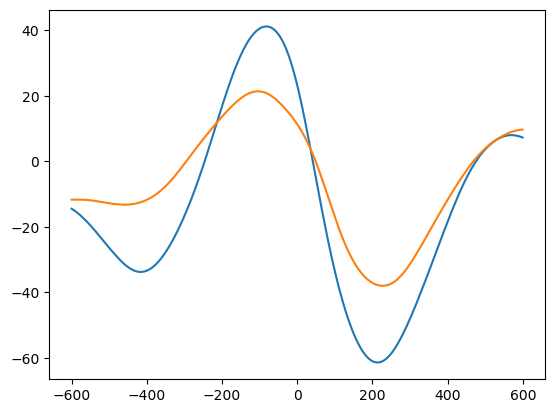

In [32]:
furn_notilt = df.FUR_BHN.values - df.ROMY_BJN.values
fure_notilt = df.FUR_BHE.values - df.ROMY_BJE.values

vr_n, sh_n = grid_reduction(df.FUR_BHN, df.ROMY_BJN, nshift_max=600)
furn_notilt = np.roll(df.FUR_BHN, sh_n) - df.ROMY_BJN

vr_e, sh_e = grid_reduction(df.FUR_BHE, df.ROMY_BJE, nshift_max=600)
fure_notilt = np.roll(df.FUR_BHE, sh_e) - df.ROMY_BJE

In [33]:
furn_romy = __modelling(df, variables=["ROMY_BJN"], target="FUR_BHN",
                        mode=mode, inter=False, verbose=True
                       )
fure_romy = __modelling(df, variables=["ROMY_BJE"], target="FUR_BHE",
                        mode=mode, inter=False, verbose=True
                       )


fit: ['ROMY_BJN']
R2: 0.20678608816690291
IC:  -6.392122466632222e-11
Coef:  [0.11802497]
ROMY_BJN : 0.11802497272114719
fit: ['ROMY_BJE']
R2: 0.11525303691228739
IC:  3.827382044800932e-11
Coef:  [0.08723906]
ROMY_BJE : 0.08723905557265756


### Plotting

In [34]:
def find_minimum(arr1, arr2, plot=True):

    from numpy import unravel_index
    from functions.variance_reduction import __variance_reduction

    dshft = 1
    shifts = np.arange(-500, 500+dshft, dshft)

    dfac = 0.01
    factors = np.arange(0.1, 1+dfac, dfac)

    Ns, Nf = len(shifts), len(factors)
    vr = np.zeros((Ns, Nf))

    for i, s in enumerate(shifts):
        for j, f in enumerate(factors):

            _arr1 = f*np.roll(arr1, s)

            vr[i, j] = __variance_reduction(arr2, arr2 -_arr1)

    imax, jmax = unravel_index(vr.argmax(), vr.shape)

    vr_max, s_max, f_max = round(vr[imax, jmax], 1), round(shifts[imax], 0), round(factors[jmax], 2)

    if plot:

        fig = plt.figure()

        cm = plt.pcolormesh(shifts,
                            factors,
                            vr[:-1, :-1].T,
                            rasterized=True,
                            cmap=plt.colormaps.get("seismic"),
                            vmin=-100, vmax=100,
                           )

        plt.scatter(s_max, f_max, color="black", s=15, edgecolor="w")

        plt.text(0, 0.99, f"{s_max}, {f_max}, {vr_max}%", ha='center', va='top', color="w")

        plt.xlabel("Shifts (samples)")
        plt.ylabel("Scaling Factor")

        cb = plt.colorbar(cm)
        cb.set_label("Variance Reduction (%)")

    return s_max, f_max, vr_max

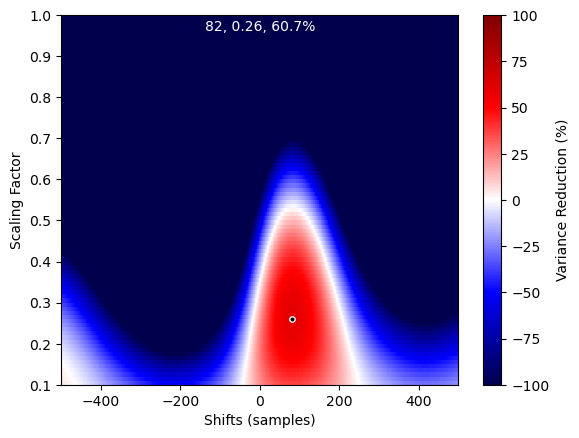

In [35]:
smax_n, fmax_n, vrmax_n = find_minimum(df['ROMY_BJN'], df['FUR_BHN'])

df['romy_fur_n_res'] = df['FUR_BHN'] - fmax_n * np.roll(df['ROMY_BJN'], smax_n)

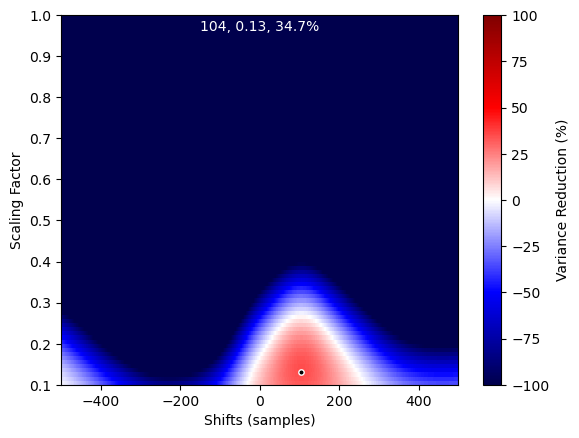

In [36]:
smax_e, fmax_e, vrmax_e = find_minimum(df['ROMY_BJE'], df['FUR_BHE'])

df['romy_fur_e_res'] = df['FUR_BHE'] - fmax_e * np.roll(df['ROMY_BJE'], smax_e)

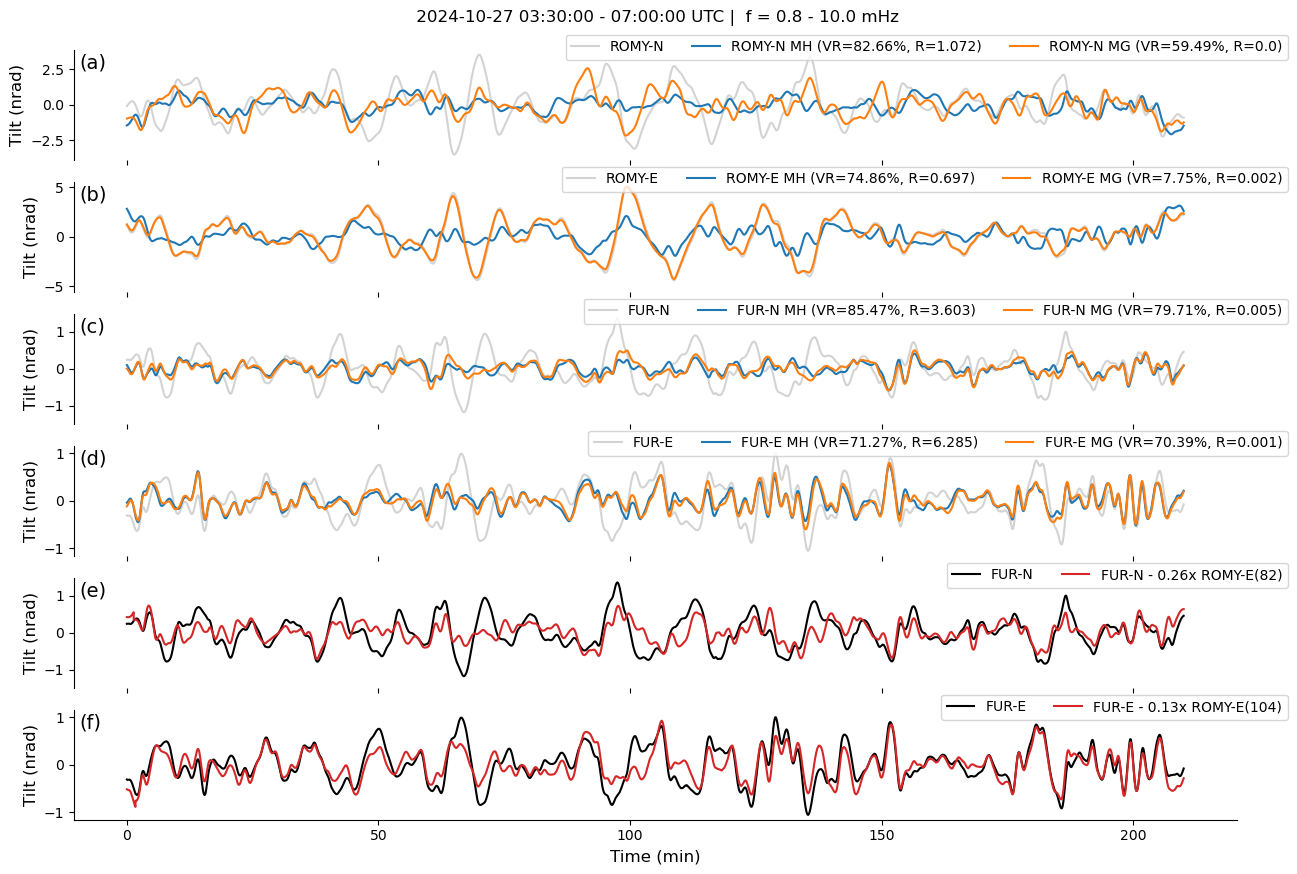

In [49]:
def __makeplot5():

    Nrow, Ncol = 6, 1

    fig, ax = plt.subplots(Nrow, Ncol, figsize=(15, 10), sharex=True)

    font = 12

    yscale, yunit = 1e9, "nrad"

    tscale, tunit = 1/60, "min"

    dsig = r"$\Delta \sigma$"

    ax[0].plot(df['time']*tscale, df['ROMY_BJN']*yscale, label="ROMY-N", color="lightgrey")
    ax[0].plot(romyn_h['time']*tscale, romyn_h['residual']*yscale, label=f"ROMY-N MH (VR={romyn_h['vr']}%, R={romyn_h['ratio']})")
    ax[0].plot(romyn_g['time']*tscale, romyn_g['residual']*yscale, label=f"ROMY-N MG (VR={romyn_g['vr']}%, R={romyn_g['ratio']})")

    ax[1].plot(df['time']*tscale, df['ROMY_BJE']*yscale, label="ROMY-E", color="lightgrey")
    ax[1].plot(romye_h['time']*tscale, romye_h['residual']*yscale, label=f"ROMY-E MH (VR={romye_h['vr']}%, R={romye_h['ratio']})")
    ax[1].plot(romye_g['time']*tscale, romye_g['residual']*yscale, label=f"ROMY-E MG (VR={romye_g['vr']}%, R={romye_g['ratio']})")

    ax[2].plot(df['time']*tscale, df['FUR_BHN']*yscale, label="FUR-N", color="lightgrey")
    ax[2].plot(furn_h['time']*tscale, furn_h['residual']*yscale, label=f"FUR-N MH (VR={furn_h['vr']}%, R={furn_h['ratio']})")
    ax[2].plot(furn_g['time']*tscale, furn_g['residual']*yscale, label=f"FUR-N MG (VR={furn_g['vr']}%, R={furn_g['ratio']})")

    ax[3].plot(df['time']*tscale, df['FUR_BHE']*yscale, label="FUR-E", color="lightgrey")
    ax[3].plot(fure_h['time']*tscale, fure_h['residual']*yscale, label=f"FUR-E MH (VR={fure_h['vr']}%, R={fure_h['ratio']})")
    ax[3].plot(fure_g['time']*tscale, fure_g['residual']*yscale, label=f"FUR-E MG (VR={fure_g['vr']}%, R={fure_g['ratio']})")

    ax[4].plot(df['time']*tscale, df['FUR_BHN']*yscale, label="FUR-N", color="k")
    ax[4].plot(df['time']*tscale, df['romy_fur_n_res']*yscale,
               label=f"FUR-N - {fmax_n}x ROMY-E({smax_n})", color="tab:red"
              )
    # ax[4].plot(furn_romy['time']*tscale, furn_romy['residual']*yscale, label=f"FUR-N -  {round(furn_romy['slopes'][0], 2)}x ROMY-N")

    ax[5].plot(df['time']*tscale, df['FUR_BHE']*yscale, label="FUR-E", color="k")
    ax[5].plot(df['time']*tscale, df['romy_fur_e_res']*yscale,
               label=f"FUR-E - {fmax_e}x ROMY-E({smax_e})", color="tab:red"
              )
    # ax[5].plot(fure_romy['time']*tscale, fure_romy['residual']*yscale, label=f"FUR-E - {round(fure_romy['slopes'][0], 2)}x ROMY-E")

    # ax[0].text(0.5, .97, romyn_g['vr'], ha='right', va='top', transform=ax[0].transAxes, fontsize=font-1)

    ax[Nrow-1].set_xlabel(f"Time ({tunit})", fontsize=font)

    ax[0].set_title(f" {config['tbeg'].date} {str(config['tbeg'].time).split('.')[0]} - {str(config['tend'].time).split('.')[0]} UTC |  f = {config['fmin']*1e3} - {config['fmax']*1e3} mHz",
                    fontsize=font, pad=20)

    for i in range(Nrow):
        ax[i].legend(loc=1, ncol=3, bbox_to_anchor=(1.05, 1.2))
        ax[i].spines[['right', 'top']].set_visible(False)
        if i < Nrow-1:
            ax[i].spines[['bottom']].set_visible(False)

        yl = max([abs(y) for y in ax[i].get_ylim()])
        ax[i].set_ylim(-yl, yl)

        ax[i].set_ylabel(f"Tilt ({yunit})", fontsize=font)

    for _k, ll in enumerate(['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']):
        ax[_k].text(.005, .97, ll, ha='left', va='top', transform=ax[_k].transAxes, fontsize=font+2)

    plt.show();
    return fig

fig = __makeplot5()

fig.savefig(config['path_to_figs']+f"RB_{config['tbeg'].date}_gradient_model_comparison.png", format="png", dpi=150, bbox_inches='tight')


In [38]:
df['romyn_g_res'] = romyn_g['residual']
df['romyn_h_res'] = romyn_h['residual']

df['romye_g_res'] = romye_g['residual']
df['romye_h_res'] = romye_h['residual']

df['furn_g_res'] = furn_g['residual']
df['furn_h_res'] = furn_h['residual']

df['fure_g_res'] = fure_g['residual']
df['fure_h_res'] = fure_h['residual']

In [39]:
def to_dff(dfx, db=True):

    from numpy import log10
    from functions.get_fft import __get_fft

    dfft = DataFrame()

    dt = int(dfx.time.diff().mean())

    scale = 1e9

    for k in dfx.keys():
        if k == "time":
            continue
        else:
            s, f, p = __get_fft(dfx[k].values*scale, dt, window="hann")

        if db:
            dfft[k] = 20*log10(s)
        else:
            dfft[k] = s

    dfft['freq'] = f

    return dfft

In [40]:
dfft = to_dff(df)

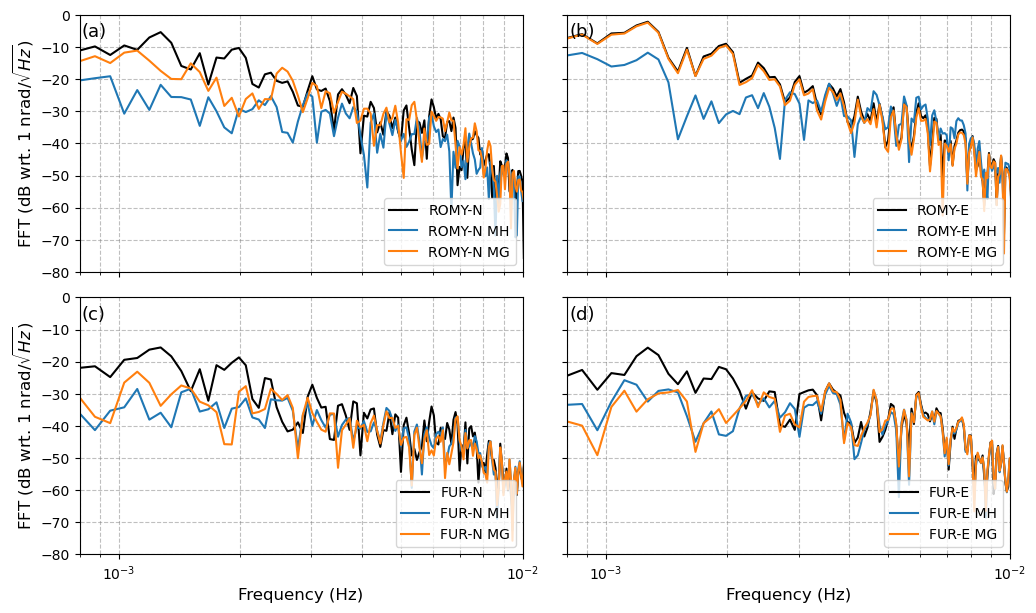

In [41]:
def __makeplot():

    import matplotlib.pyplot as plt

    Nrow, Ncol = 2, 2

    font = 12

    fig, ax = plt.subplots(Nrow, Ncol, figsize=(12, 7), sharex=True, sharey=True)

    plt.subplots_adjust(hspace=0.1, wspace=0.1)

    ax[0, 0].plot(dfft['freq'], dfft.ROMY_BJN, color="k", label="ROMY-N")
    ax[0, 0].plot(dfft['freq'], dfft.romyn_h_res, label="ROMY-N MH")
    ax[0, 0].plot(dfft['freq'], dfft.romyn_g_res, label="ROMY-N MG")

    ax[1, 0].plot(dfft['freq'], dfft.FUR_BHN, color="k", label="FUR-N")
    ax[1, 0].plot(dfft['freq'], dfft.furn_h_res, label="FUR-N MH")
    ax[1, 0].plot(dfft['freq'], dfft.furn_g_res, label="FUR-N MG")

    ax[0, 1].plot(dfft['freq'], dfft.ROMY_BJE, color="k", label="ROMY-E")
    ax[0, 1].plot(dfft['freq'], dfft.romye_h_res, label="ROMY-E MH")
    ax[0, 1].plot(dfft['freq'], dfft.romye_g_res, label="ROMY-E MG")

    ax[1, 1].plot(dfft['freq'], dfft.FUR_BHE, color="k", label="FUR-E")
    ax[1, 1].plot(dfft['freq'], dfft.fure_h_res, label="FUR-E MH")
    ax[1, 1].plot(dfft['freq'], dfft.fure_g_res, label="FUR-E MG")

    ax[0, 0].set_xscale("log")

    for j in range(Nrow):
        for i in range(Ncol):
            ax[j, i].grid(which="both", ls="--", color="grey", alpha=0.5, zorder=0)
            ax[j, i].set_xlim(config['fmin'], config['fmax'])
            ax[j, i].set_ylim(-80, 0)
            ax[j, i].legend(loc=4)

    ax[0, 0].text(0.005, 0.97, "(a)", ha="left", va="top", transform=ax[0, 0].transAxes, fontsize=font+1)
    ax[0, 1].text(0.005, 0.97, "(b)", ha="left", va="top", transform=ax[0, 1].transAxes, fontsize=font+1)
    ax[1, 0].text(0.005, 0.97, "(c)", ha="left", va="top", transform=ax[1, 0].transAxes, fontsize=font+1)
    ax[1, 1].text(0.005, 0.97, "(d)", ha="left", va="top", transform=ax[1, 1].transAxes, fontsize=font+1)

    ax[0, 0].set_ylabel("FFT (dB wrt. 1 nrad/$\sqrt{Hz}$)", fontsize=font)
    ax[1, 0].set_ylabel("FFT (dB wrt. 1 nrad/$\sqrt{Hz}$)", fontsize=font)
    ax[1, 0].set_xlabel("Frequency (Hz)", fontsize=font)
    ax[1, 1].set_xlabel("Frequency (Hz)", fontsize=font)

    plt.show();
    return fig

fig = __makeplot();

fig.savefig(config['path_to_figs']+f"RB_{config['tbeg'].date}_gradient_model_comparison_spectra.png", format="png", dpi=150, bbox_inches='tight')


In [42]:
romyn = stall.select(station="ROMY", component="N")[0].data*1e9
furn = stall.select(station="FUR", component="N")[0].data*1e9

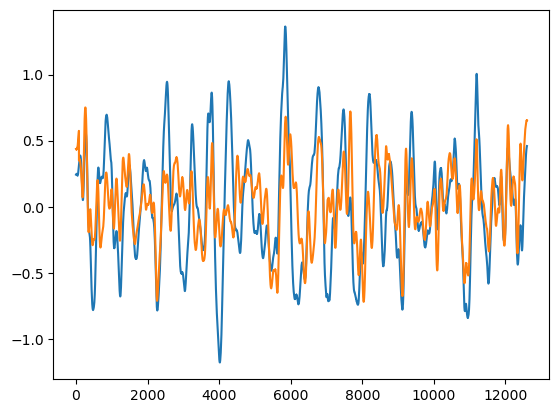

In [43]:
plt.plot(furn)
plt.plot(furn - .28 * np.roll(romyn, 82))

(82, 0.26, 60.7)

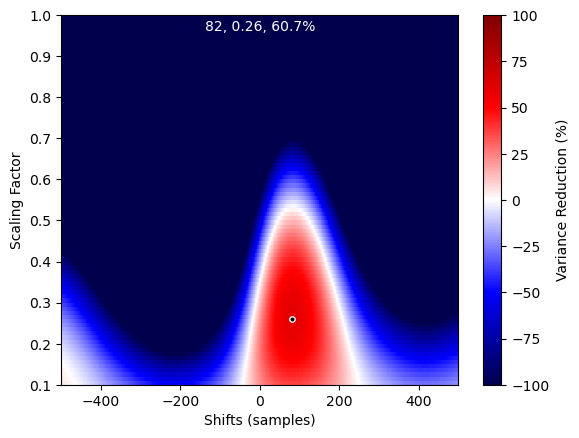

In [44]:
romyn = stall.select(station="ROMY", component="N")[0].data*1e9
furn = stall.select(station="FUR", component="N")[0].data*1e9

find_minimum(romyn, furn)

(104, 0.13, 34.7)

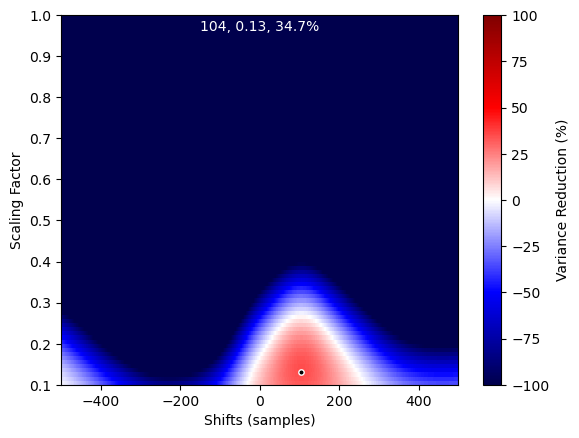

In [45]:
romye = stall.select(station="ROMY", component="E")[0].data*1e9
fure = stall.select(station="FUR", component="E")[0].data*1e9

find_minimum(romye, fure)